In [15]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.spatial.distance import mahalanobis
from data_processing import load_and_prepare_data

def prepare_data_for_analysis(df):
    """
    Prepare clean data for multivariate statistical analysis
    """
    # Select the key parameters for analysis
    analysis_features = ['pl_rade', 'pl_eqt', 'pl_insol', 'pl_dens', 
                        'st_teff', 'st_rad', 'st_mass', 'st_met']
    
    # Create a clean dataset with no missing values
    df_clean = df[analysis_features + ['pl_name', 'planet_category']].dropna().copy()
    
    print(f"Analysis dataset: {len(df_clean)} planets with complete data")
    print(f"Original dataset: {len(df)} planets total")
    print(f"Data completeness: {len(df_clean)/len(df)*100:.1f}%")
    
    return df_clean, analysis_features

In [17]:
def categorize_planets_advanced(df, good_ranges):
    """
    Categorize planets based on multiple criteria for colonization potential
    """
    categories = []
    
    for _, row in df.iterrows():
        planetary_features = ['pl_rade', 'pl_eqt', 'pl_insol', 'pl_dens']
        stellar_features = ['st_teff', 'st_rad', 'st_mass', 'st_met']
        
        # Check for missing data
        missing_planetary = any(pd.isna(row[feat]) for feat in planetary_features)
        missing_stellar = any(pd.isna(row[feat]) for feat in stellar_features)
        
        if missing_planetary and missing_stellar:
            categories.append('Insufficient Data')
            continue
        elif missing_planetary:
            categories.append('Missing Planetary Data')
            continue
        elif missing_stellar:
            categories.append('Missing Stellar Data')
            continue
        
        # Check planetary habitability
        planetary_good = True
        for feat in planetary_features:
            if feat in good_ranges:
                min_val, max_val = good_ranges[feat]
                if not (min_val <= row[feat] <= max_val):
                    planetary_good = False
                    break
        
        # Check stellar habitability
        stellar_good = True
        for feat in stellar_features:
            if feat in good_ranges:
                min_val, max_val = good_ranges[feat]
                if not (min_val <= row[feat] <= max_val):
                    stellar_good = False
                    break
        
        # Categorize based on results
        if planetary_good and stellar_good:
            categories.append('Excellent Candidate')
        elif planetary_good:
            categories.append('Good Planet, Poor Star')
        elif stellar_good:
            categories.append('Good Star, Poor Planet')
        else:
            # Further subcategorize problems
            temp = row['pl_eqt']
            if temp < good_ranges['pl_eqt'][0]:
                categories.append('Too Cold')
            elif temp > good_ranges['pl_eqt'][1]:
                categories.append('Too Hot')
            elif row['pl_rade'] > good_ranges['pl_rade'][1]:
                categories.append('Too Large (Gas Giant)')
            elif row['pl_rade'] < good_ranges['pl_rade'][0]:
                categories.append('Too Small')
            else:
                categories.append('Other Issues')
    
    return categories

In [19]:
def hotellings_t2_test(df_clean, analysis_features):
    """
    Perform Hotelling's T² Test to compare Excellent Candidates vs All Others
    """
    print("\n🔬 HOTELLING'S T² TEST:")
    print("=" * 60)
    
    # Separate groups
    excellent_mask = df_clean['planet_category'] == 'Excellent Candidate'
    excellent_group = df_clean[excellent_mask][analysis_features]
    others_group = df_clean[~excellent_mask][analysis_features]
    
    print(f"Excellent Candidates: {len(excellent_group)} planets")
    print(f"All Others: {len(others_group)} planets")
    
    if len(excellent_group) < 2:
        print("⚠️  WARNING: Need at least 2 Excellent Candidates for T² test")
        print("    Switching to single-sample test against population mean")
        
        # Single observation test (Earth vs population)
        if len(excellent_group) == 1:
            earth_values = excellent_group.iloc[0].values
            population_mean = others_group.mean().values
            population_cov = others_group.cov().values
            
            # Calculate T² for single observation
            diff = earth_values - population_mean
            try:
                cov_inv = np.linalg.inv(population_cov)
                t2_stat = np.dot(np.dot(diff, cov_inv), diff) * len(others_group)
                
                # Convert to F-statistic
                p = len(analysis_features)  # number of variables
                n = len(others_group)       # sample size of comparison group
                f_stat = t2_stat * (n - p) / (p * (n - 1))
                df1, df2 = p, n - p
                p_value = 1 - stats.f.cdf(f_stat, df1, df2)
                
                print(f"\nSINGLE-SAMPLE T² TEST RESULTS:")
                print(f"T² statistic: {t2_stat:.4f}")
                print(f"F-statistic: {f_stat:.4f}")
                print(f"Degrees of freedom: ({df1}, {df2})")
                print(f"P-value: {p_value:.6f}")
                
                if p_value < 0.05:
                    print(f"🎯 RESULT: Earth is SIGNIFICANTLY different from other planets (p < 0.05)")
                else:
                    print(f"📊 RESULT: Earth is NOT significantly different from other planets (p ≥ 0.05)")
                    
                return t2_stat, f_stat, p_value, df1, df2
                
            except np.linalg.LinAlgError:
                print("❌ ERROR: Singular covariance matrix - cannot perform test")
                return None, None, None, None, None
    else:
        # Two-sample Hotelling's T² test
        n1, n2 = len(excellent_group), len(others_group)
        p = len(analysis_features)
        
        # Calculate means
        mean1 = excellent_group.mean().values
        mean2 = others_group.mean().values
        
        # Calculate pooled covariance matrix
        cov1 = excellent_group.cov().values
        cov2 = others_group.cov().values
        pooled_cov = ((n1 - 1) * cov1 + (n2 - 1) * cov2) / (n1 + n2 - 2)
        
        try:
            # Calculate T² statistic
            diff = mean1 - mean2
            cov_inv = np.linalg.inv(pooled_cov)
            t2_stat = (n1 * n2 / (n1 + n2)) * np.dot(np.dot(diff, cov_inv), diff)
            
            # Convert to F-statistic
            f_stat = t2_stat * (n1 + n2 - p - 1) / (p * (n1 + n2 - 2))
            df1, df2 = p, n1 + n2 - p - 1
            p_value = 1 - stats.f.cdf(f_stat, df1, df2)
            
            print(f"\nTWO-SAMPLE T² TEST RESULTS:")
            print(f"T² statistic: {t2_stat:.4f}")
            print(f"F-statistic: {f_stat:.4f}")
            print(f"Degrees of freedom: ({df1}, {df2})")
            print(f"P-value: {p_value:.6f}")
            
            if p_value < 0.05:
                print(f"🎯 RESULT: Excellent Candidates are SIGNIFICANTLY different from other planets")
            else:
                print(f"📊 RESULT: Excellent Candidates are NOT significantly different from other planets")
                
            return t2_stat, f_stat, p_value, df1, df2
            
        except np.linalg.LinAlgError:
            print("❌ ERROR: Singular covariance matrix - cannot perform test")
            return None, None, None, None, None

In [23]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.spatial.distance import mahalanobis

def prepare_data_for_analysis(df):
    """
    Prepare clean data for multivariate statistical analysis
    """
    # Select the key parameters for analysis
    analysis_features = ['pl_rade', 'pl_eqt', 'pl_insol', 'pl_dens', 
                        'st_teff', 'st_rad', 'st_mass', 'st_met']
    
    # Create a clean dataset with no missing values
    df_clean = df[analysis_features + ['pl_name', 'planet_category']].dropna().copy()
    
    print(f"Analysis dataset: {len(df_clean)} planets with complete data")
    print(f"Original dataset: {len(df)} planets total")
    print(f"Data completeness: {len(df_clean)/len(df)*100:.1f}%")
    
    return df_clean, analysis_features

def hotellings_t2_test(df_clean, analysis_features):
    """
    Perform Hotelling's T² Test to compare Excellent Candidates vs All Others
    """
    print("\n🔬 HOTELLING'S T² TEST:")
    print("=" * 60)
    
    # Separate groups
    excellent_mask = df_clean['planet_category'] == 'Excellent Candidate'
    excellent_group = df_clean[excellent_mask][analysis_features]
    others_group = df_clean[~excellent_mask][analysis_features]
    
    print(f"Excellent Candidates: {len(excellent_group)} planets")
    print(f"All Others: {len(others_group)} planets")
    
    if len(excellent_group) < 2:
        print("⚠️  WARNING: Need at least 2 Excellent Candidates for T² test")
        print("    Switching to single-sample test against population mean")
        
        # Single observation test (Earth vs population)
        if len(excellent_group) == 1:
            earth_values = excellent_group.iloc[0].values
            population_mean = others_group.mean().values
            population_cov = others_group.cov().values
            
            # Calculate T² for single observation
            diff = earth_values - population_mean
            try:
                cov_inv = np.linalg.inv(population_cov)
                t2_stat = np.dot(np.dot(diff, cov_inv), diff) * len(others_group)
                
                # Convert to F-statistic
                p = len(analysis_features)  # number of variables
                n = len(others_group)       # sample size of comparison group
                f_stat = t2_stat * (n - p) / (p * (n - 1))
                df1, df2 = p, n - p
                p_value = 1 - stats.f.cdf(f_stat, df1, df2)
                
                print(f"\nSINGLE-SAMPLE T² TEST RESULTS:")
                print(f"T² statistic: {t2_stat:.4f}")
                print(f"F-statistic: {f_stat:.4f}")
                print(f"Degrees of freedom: ({df1}, {df2})")
                print(f"P-value: {p_value:.6f}")
                
                if p_value < 0.05:
                    print(f"🎯 RESULT: Earth is SIGNIFICANTLY different from other planets (p < 0.05)")
                else:
                    print(f"📊 RESULT: Earth is NOT significantly different from other planets (p ≥ 0.05)")
                    
                return t2_stat, f_stat, p_value, df1, df2
                
            except np.linalg.LinAlgError:
                print("❌ ERROR: Singular covariance matrix - cannot perform test")
                return None, None, None, None, None
    else:
        # Two-sample Hotelling's T² test
        n1, n2 = len(excellent_group), len(others_group)
        p = len(analysis_features)
        
        # Calculate means
        mean1 = excellent_group.mean().values
        mean2 = others_group.mean().values
        
        # Calculate pooled covariance matrix
        cov1 = excellent_group.cov().values
        cov2 = others_group.cov().values
        pooled_cov = ((n1 - 1) * cov1 + (n2 - 1) * cov2) / (n1 + n2 - 2)
        
        try:
            # Calculate T² statistic
            diff = mean1 - mean2
            cov_inv = np.linalg.inv(pooled_cov)
            t2_stat = (n1 * n2 / (n1 + n2)) * np.dot(np.dot(diff, cov_inv), diff)
            
            # Convert to F-statistic
            f_stat = t2_stat * (n1 + n2 - p - 1) / (p * (n1 + n2 - 2))
            df1, df2 = p, n1 + n2 - p - 1
            p_value = 1 - stats.f.cdf(f_stat, df1, df2)
            
            print(f"\nTWO-SAMPLE T² TEST RESULTS:")
            print(f"T² statistic: {t2_stat:.4f}")
            print(f"F-statistic: {f_stat:.4f}")
            print(f"Degrees of freedom: ({df1}, {df2})")
            print(f"P-value: {p_value:.6f}")
            
            if p_value < 0.05:
                print(f"🎯 RESULT: Excellent Candidates are SIGNIFICANTLY different from other planets")
            else:
                print(f"📊 RESULT: Excellent Candidates are NOT significantly different from other planets")
                
            return t2_stat, f_stat, p_value, df1, df2
            
        except np.linalg.LinAlgError:
            print("❌ ERROR: Singular covariance matrix - cannot perform test")
            return None, None, None, None, None

def calculate_mahalanobis_distances(df_clean, analysis_features):
    """
    Calculate Mahalanobis distances for all planets from the population center
    """
    print("\n📏 MAHALANOBIS DISTANCE ANALYSIS:")
    print("=" * 60)
    
    # Get the feature matrix
    X = df_clean[analysis_features].values
    
    # Calculate population statistics
    population_mean = np.mean(X, axis=0)
    population_cov = np.cov(X, rowvar=False)
    
    try:
        cov_inv = np.linalg.inv(population_cov)
    except np.linalg.LinAlgError:
        print("❌ ERROR: Singular covariance matrix, using pseudoinverse")
        cov_inv = np.linalg.pinv(population_cov)
    
    # Calculate Mahalanobis distance for each planet
    mahal_distances = []
    for i in range(len(X)):
        dist = mahalanobis(X[i], population_mean, cov_inv)
        mahal_distances.append(dist)
    
    # Add distances to dataframe
    df_with_distances = df_clean.copy()
    df_with_distances['mahalanobis_distance'] = mahal_distances
    
    # Sort by distance (most unusual first)
    df_sorted = df_with_distances.sort_values('mahalanobis_distance', ascending=False)
    
    print(f"Population mean calculated from {len(X)} planets")
    print(f"\nTOP 10 MOST UNUSUAL PLANETS (Highest Mahalanobis Distance):")
    print("-" * 70)
    print(f"{'Rank':<4} | {'Planet Name':<20} | {'Category':<20} | {'Distance':<10}")
    print("-" * 70)
    
    for i, (_, planet) in enumerate(df_sorted.head(10).iterrows(), 1):
        name = planet['pl_name'][:18]  # Truncate long names
        category = planet['planet_category'][:18]
        distance = planet['mahalanobis_distance']
        print(f"{i:<4} | {name:<20} | {category:<20} | {distance:<10.3f}")
    
    # Focus on Earth and Kepler-22 b specifically
    print(f"\n🌍 SPECIFIC ANALYSIS FOR KEY PLANETS:")
    print("-" * 50)
    
    earth_row = df_with_distances[df_with_distances['pl_name'].str.contains('Earth', case=False, na=False)]
    if not earth_row.empty:
        earth_distance = earth_row['mahalanobis_distance'].iloc[0]
        earth_rank = (df_with_distances['mahalanobis_distance'] > earth_distance).sum() + 1
        print(f"Earth:")
        print(f"  Mahalanobis Distance: {earth_distance:.3f}")
        print(f"  Rank (unusualness): {earth_rank} out of {len(df_with_distances)}")
        print(f"  Percentile: {(1 - earth_rank/len(df_with_distances))*100:.1f}%")
    
    kepler_row = df_with_distances[df_with_distances['pl_name'].str.contains('Kepler-22', case=False, na=False)]
    if not kepler_row.empty:
        kepler_distance = kepler_row['mahalanobis_distance'].iloc[0]
        kepler_rank = (df_with_distances['mahalanobis_distance'] > kepler_distance).sum() + 1
        print(f"\nKepler-22 b:")
        print(f"  Mahalanobis Distance: {kepler_distance:.3f}")
        print(f"  Rank (unusualness): {kepler_rank} out of {len(df_with_distances)}")
        print(f"  Percentile: {(1 - kepler_rank/len(df_with_distances))*100:.1f}%")
    
    # Statistical interpretation
    print(f"\n📊 STATISTICAL INTERPRETATION:")
    print("-" * 40)
    
    # Chi-square critical values for outlier detection
    p_values = len(analysis_features)
    chi2_95 = stats.chi2.ppf(0.95, p_values)
    chi2_99 = stats.chi2.ppf(0.99, p_values)
    
    outliers_95 = (df_with_distances['mahalanobis_distance'] > np.sqrt(chi2_95)).sum()
    outliers_99 = (df_with_distances['mahalanobis_distance'] > np.sqrt(chi2_99)).sum()
    
    print(f"Mahalanobis distance follows chi-square distribution with {p_values} degrees of freedom")
    print(f"Critical values (distance threshold):")
    print(f"  95% confidence: {np.sqrt(chi2_95):.3f}")
    print(f"  99% confidence: {np.sqrt(chi2_99):.3f}")
    print(f"\nOutliers detected:")
    print(f"  At 95% level: {outliers_95} planets ({outliers_95/len(df_with_distances)*100:.1f}%)")
    print(f"  At 99% level: {outliers_99} planets ({outliers_99/len(df_with_distances)*100:.1f}%)")
    
    # Check if Earth and Kepler-22b are outliers
    if not earth_row.empty:
        earth_distance = earth_row['mahalanobis_distance'].iloc[0]
        earth_outlier_95 = earth_distance > np.sqrt(chi2_95)
        earth_outlier_99 = earth_distance > np.sqrt(chi2_99)
        print(f"\nEarth outlier status:")
        print(f"  95% level: {'YES ✓' if earth_outlier_95 else 'NO ✗'}")
        print(f"  99% level: {'YES ✓' if earth_outlier_99 else 'NO ✗'}")
    
    if not kepler_row.empty:
        kepler_distance = kepler_row['mahalanobis_distance'].iloc[0]
        kepler_outlier_95 = kepler_distance > np.sqrt(chi2_95)
        kepler_outlier_99 = kepler_distance > np.sqrt(chi2_99)
        print(f"\nKepler-22 b outlier status:")
        print(f"  95% level: {'YES ✓' if kepler_outlier_95 else 'NO ✗'}")
        print(f"  99% level: {'YES ✓' if kepler_outlier_99 else 'NO ✗'}")
    
    return df_with_distances, chi2_95, chi2_99

In [25]:
def comprehensive_multivariate_analysis(df_with_categories, good_ranges):
    """
    Complete multivariate analysis combining T² test and Mahalanobis distances
    """
    print("🎯 COMPREHENSIVE MULTIVARIATE STATISTICAL ANALYSIS")
    print("=" * 70)
    
    # Step 1: Prepare data
    df_clean, analysis_features = prepare_data_for_analysis(df_with_categories)
    
    # Step 2: Hotelling's T² Test
    t2_results = hotellings_t2_test(df_clean, analysis_features)
    
    # Step 3: Mahalanobis Distance Analysis
    df_with_distances, chi2_95, chi2_99 = calculate_mahalanobis_distances(df_clean, analysis_features)
    
    return df_with_distances, t2_results

In [27]:
# Fixed Main execution with very_relaxed criteria - ENSURES Earth data is correct
if __name__ == "__main__":
    
    # Use very_relaxed ranges for maximum statistical power
    RANGE_PREFERENCE = "very_relaxed"
    
    # Define threshold sets
    good_ranges_sets = {
        "original": {
            "pl_rade": (0.5, 3.0),
            "pl_eqt": (180, 310),
            "pl_insol": (0.25, 3.0),
            "pl_dens": (3.0, 8.0),
            "st_teff": (4000, 6500),
            "st_rad": (0.6, 1.4),
            "st_mass": (0.5, 1.5),
            "st_met": (-0.5, 0.5),
        },
        "refined": {
            "pl_rade": (0.8, 1.7),
            "pl_eqt": (200, 300),
            "pl_insol": (0.5, 1.4),
            "pl_dens": (4.0, 7.0),
            "st_teff": (4500, 6200),
            "st_rad": (0.7, 1.3),
            "st_mass": (0.6, 1.2),
            "st_met": (-0.2, 0.3),
        },
        "relaxed": {
            "pl_rade": (0.5, 2.5),
            "pl_eqt": (150, 350),
            "pl_insol": (0.2, 2.2),
            "pl_dens": (3.0, 9.0),
            "st_teff": (4000, 6800),
            "st_rad": (0.5, 1.6),
            "st_mass": (0.4, 1.6),
            "st_met": (-0.4, 0.5),
        },
        "very_relaxed": {
            "pl_rade": (0.4, 3.0),      # Very inclusive planet radius
            "pl_eqt": (130, 400),       # Very broad temperature range
            "pl_insol": (0.1, 3.0),     # Very inclusive insolation
            "pl_dens": (2.5, 10.0),     # Very broad density range
            "st_teff": (3800, 7200),    # Include late M to early F stars
            "st_rad": (0.4, 1.8),       # Very broad stellar radius
            "st_mass": (0.3, 1.8),      # Very broad stellar mass
            "st_met": (-0.6, 0.6),      # Very broad metallicity
        },
        "earth_like": {
            "pl_rade": (0.9, 1.3),
            "pl_eqt": (250, 290),
            "pl_insol": (0.8, 1.2),
            "pl_dens": (4.5, 6.5),
            "st_teff": (5000, 6000),
            "st_rad": (0.8, 1.2),
            "st_mass": (0.8, 1.1),
            "st_met": (-0.1, 0.2),
        }
    }
    
    # ✅ Load the prepared dataset
    try:
        df = load_and_prepare_data("Data/Planetary-Systems-May-20-2025_clean.csv")
    except NameError:
        # Fallback to manual loading if function not available
        print("load_and_prepare_data not found, loading manually...")
        df = pd.read_csv("Data/Planetary-Systems-May-20-2025_clean.csv")
        
        # Add distance calculation
        PARSEC_TO_LY = 3.26156
        df["sy_dist_ly"] = df["sy_dist"] * PARSEC_TO_LY
    
    # Check if data loaded successfully
    if df is None:
        raise RuntimeError("❌ Failed to load data. Check your path or preprocessing logic.")
    
    print(f"✅ Loaded {len(df)} planets successfully")
    
    # ✅ PROPERLY ADD EARTH DATA - Force add with all required columns
    print("🔄 Adding complete Earth data...")
    
    # Remove any existing Earth entries first
    df = df[~df["pl_name"].astype(str).str.contains("Earth", case=False, na=False)]
    
    # Create complete Earth data with ALL required columns
    earth_data_complete = {}
    
    # Copy a template row to ensure we have all columns
    if len(df) > 0:
        earth_data_complete = df.iloc[0].to_dict()  # Get all columns from first row
    
    # Override with correct Earth values
    earth_data_complete.update({
        "pl_name": "Earth (Sol System)",
        "hostname": "Sun",
        "sy_dist": 0.0,
        "sy_dist_ly": 0.0,
        "ra": 0.0,
        "dec": 0.0,
        # Planetary parameters
        "pl_rade": 1.0,
        "pl_eqt": 288.0,
        "pl_insol": 1.0,
        "pl_dens": 5.51,
        # Stellar parameters - CRITICAL FOR CLASSIFICATION
        "st_teff": 5778.0,     # Sun's effective temperature
        "st_rad": 1.0,         # Solar radius
        "st_mass": 1.0,        # Solar mass
        "st_met": 0.0,         # Solar metallicity
        # Other columns
        "glon": np.nan,
        "glat": np.nan,
    })
    
    # Add Earth as new row
    earth_df_row = pd.DataFrame([earth_data_complete])
    df = pd.concat([df, earth_df_row], ignore_index=True)
    
    print("✅ Earth data added successfully")
    
    # ✅ DEBUG: Check Earth data specifically
    earth_check = df[df["pl_name"].str.contains("Earth", case=False, na=False)]
    if not earth_check.empty:
        earth_row = earth_check.iloc[0]
        print(f"\n🔍 EARTH DATA VERIFICATION:")
        print("-" * 40)
        critical_params = ['pl_rade', 'pl_eqt', 'pl_insol', 'pl_dens', 'st_teff', 'st_rad', 'st_mass', 'st_met']
        for param in critical_params:
            value = earth_row[param]
            is_missing = pd.isna(value)
            print(f"{param}: {value} {'❌ MISSING' if is_missing else '✅ OK'}")
    else:
        print("❌ ERROR: Earth data not found after adding!")
    
    # ✅ Get the selected good ranges
    good_ranges = good_ranges_sets[RANGE_PREFERENCE]
    
    # ✅ Create planet categories using the good_ranges
    print(f"\n🔄 Categorizing planets using {RANGE_PREFERENCE.upper()} criteria...")
    df['planet_category'] = categorize_planets_advanced(df, good_ranges)
    
    # ✅ Show category breakdown
    print(f"\nPLANET CATEGORIZATION RESULTS:")
    print("=" * 60)
    category_counts = df['planet_category'].value_counts()
    for category, count in category_counts.items():
        percentage = (count / len(df)) * 100
        print(f"{category}: {count} planets ({percentage:.1f}%)")
    
    # ✅ Show Earth's classification specifically
    print(f"\n🌍 EARTH'S CLASSIFICATION:")
    print("=" * 30)
    earth_category = df[df["pl_name"].str.contains("Earth", case=False, na=False)]['planet_category'].iloc[0]
    print(f"Earth is classified as: {earth_category}")
    
    # ✅ If Earth is not Excellent Candidate, debug why
    if earth_category != 'Excellent Candidate':
        print(f"\n🔍 DEBUGGING EARTH'S CLASSIFICATION:")
        print("-" * 40)
        earth_row = df[df["pl_name"].str.contains("Earth", case=False, na=False)].iloc[0]
        
        planetary_features = ['pl_rade', 'pl_eqt', 'pl_insol', 'pl_dens']
        stellar_features = ['st_teff', 'st_rad', 'st_mass', 'st_met']
        
        print("Planetary features check:")
        for feat in planetary_features:
            value = earth_row[feat]
            if pd.isna(value):
                print(f"  {feat}: MISSING ❌")
            else:
                min_val, max_val = good_ranges[feat]
                in_range = min_val <= value <= max_val
                print(f"  {feat}: {value} (range: {min_val}-{max_val}) {'✅' if in_range else '❌'}")
        
        print("Stellar features check:")
        for feat in stellar_features:
            value = earth_row[feat]
            if pd.isna(value):
                print(f"  {feat}: MISSING ❌")
            else:
                min_val, max_val = good_ranges[feat]
                in_range = min_val <= value <= max_val
                print(f"  {feat}: {value} (range: {min_val}-{max_val}) {'✅' if in_range else '❌'}")
    
    # ✅ Show excellent candidates
    df_with_categories = df
    excellent_candidates = df_with_categories[df_with_categories['planet_category'] == 'Excellent Candidate']
    
    print(f"\n🌟 EXCELLENT CANDIDATES FOUND:")
    print("=" * 40)
    if len(excellent_candidates) > 0:
        for i, (_, planet) in enumerate(excellent_candidates.iterrows(), 1):
            print(f"{i}. {planet['pl_name']}")
            if planet['pl_name'] != "Earth (Sol System)":
                print(f"   Distance: {planet.get('sy_dist_ly', 0):.1f} light years")
        print(f"\nTotal: {len(excellent_candidates)} excellent candidates")
    else:
        print("No excellent candidates found with current criteria!")
        print("This suggests the criteria might be too strict or there's a data issue.")
    
    # ✅ Show threshold information
    print(f"\nTHRESHOLD SET USED: {RANGE_PREFERENCE.upper()}")
    print("=" * 30)
    print("Very Relaxed Criteria Ranges:")
    for param, (min_val, max_val) in good_ranges.items():
        print(f"  {param}: ({min_val}, {max_val})")
    
    # ✅ Run statistical analysis only if we have excellent candidates
    if len(excellent_candidates) > 0:
        print(f"\n🚀 STARTING COMPREHENSIVE MULTIVARIATE ANALYSIS...")
        print("=" * 60)
        
        try:
            df_with_distances, t2_results = comprehensive_multivariate_analysis(df_with_categories, good_ranges)
            
            print(f"\n📋 STATISTICAL ANALYSIS COMPLETE!")
            print("=" * 40)
            print("✅ Results include:")
            print("• Hotelling's T² test for group differences")
            print("• Mahalanobis distances for all planets")
            print("• Statistical outlier detection")
            print("• Earth and excellent candidates specific analysis")
            
        except NameError as e:
            print(f"❌ ERROR: Missing function - {e}")
            print("Please make sure you have defined the statistical analysis functions.")
            
        except Exception as e:
            print(f"❌ ERROR during statistical analysis: {e}")
            
    else:
        print(f"\n⚠️  SKIPPING STATISTICAL ANALYSIS:")
        print("No excellent candidates found - cannot perform meaningful statistical tests.")
        print("Consider using more relaxed criteria or checking your data.")
    
    # ✅ Final summary
    print(f"\n🎯 FINAL SUMMARY:")
    print("=" * 30)
    print(f"Threshold used: {RANGE_PREFERENCE.upper()}")
    print(f"Total planets: {len(df_with_categories)}")
    print(f"Excellent candidates: {len(excellent_candidates)}")
    print(f"Earth classification: {earth_category}")
    
    if earth_category == 'Excellent Candidate':
        print("✅ Earth properly classified as Excellent Candidate")
    else:
        print("❌ Earth classification issue - check debug output above")
        

✅ Loaded 517 planets successfully
🔄 Adding complete Earth data...
✅ Earth data added successfully

🔍 EARTH DATA VERIFICATION:
----------------------------------------
pl_rade: 1.0 ✅ OK
pl_eqt: 288.0 ✅ OK
pl_insol: 1.0 ✅ OK
pl_dens: 5.51 ✅ OK
st_teff: 5778.0 ✅ OK
st_rad: 1.0 ✅ OK
st_mass: 1.0 ✅ OK
st_met: 0.0 ✅ OK

🔄 Categorizing planets using VERY_RELAXED criteria...

PLANET CATEGORIZATION RESULTS:
Good Star, Poor Planet: 388 planets (75.0%)
Too Hot: 97 planets (18.8%)
Missing Stellar Data: 12 planets (2.3%)
Other Issues: 8 planets (1.5%)
Good Planet, Poor Star: 6 planets (1.2%)
Too Large (Gas Giant): 3 planets (0.6%)
Excellent Candidate: 3 planets (0.6%)

🌍 EARTH'S CLASSIFICATION:
Earth is classified as: Excellent Candidate

🌟 EXCELLENT CANDIDATES FOUND:
1. Kepler-22 b
   Distance: 634.8 light years
2. Kepler-538 b
   Distance: 508.7 light years
3. Earth (Sol System)

Total: 3 excellent candidates

THRESHOLD SET USED: VERY_RELAXED
Very Relaxed Criteria Ranges:
  pl_rade: (0.4, 3.0)
  

In [90]:
# Analysis of Good Planet / Bad Stars

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_good_planet_poor_star(df_with_categories, good_ranges):
    """
    Detailed analysis of planets that meet planetary criteria but have unsuitable stars
    """
    print("🌟 DETAILED ANALYSIS: GOOD PLANET, POOR STAR")
    print("=" * 70)
    
    # Filter for Good Planet, Poor Star category
    gpps_planets = df_with_categories[
        df_with_categories['planet_category'] == 'Good Planet, Poor Star'
    ].copy()
    
    if len(gpps_planets) == 0:
        print("No 'Good Planet, Poor Star' planets found!")
        return None
    
    print(f"Found {len(gpps_planets)} planets with good planetary conditions but poor stars")
    print("\n🪐 THE 6 PLANETS WITH GOOD PLANETS BUT POOR STARS:")
    print("=" * 80)
    
    # Define parameter groups
    planetary_features = ['pl_rade', 'pl_eqt', 'pl_insol', 'pl_dens']
    stellar_features = ['st_teff', 'st_rad', 'st_mass', 'st_met']
    
    # Show each planet in detail
    for i, (idx, planet) in enumerate(gpps_planets.iterrows(), 1):
        print(f"\n🌍 PLANET #{i}: {planet['pl_name']}")
        print("-" * 50)
        print(f"Host Star: {planet.get('hostname', 'Unknown')}")
        print(f"Distance: {planet.get('sy_dist_ly', 'Unknown'):.1f} light years")
        
        # Check planetary parameters (should all pass)
        print(f"\n✅ PLANETARY PARAMETERS (Should all be GOOD):")
        for param in planetary_features:
            value = planet[param]
            if pd.notna(value) and param in good_ranges:
                min_val, max_val = good_ranges[param]
                is_good = min_val <= value <= max_val
                status = "✅ GOOD" if is_good else "❌ BAD"
                print(f"  {param:10}: {value:8.2f} (range: {min_val:5.1f}-{max_val:5.1f}) {status}")
            else:
                print(f"  {param:10}: {'N/A':8} (missing data)")
        
        # Check stellar parameters (should have failures)
        print(f"\n❌ STELLAR PARAMETERS (Why the star is 'POOR'):")
        star_issues = []
        for param in stellar_features:
            value = planet[param]
            if pd.notna(value) and param in good_ranges:
                min_val, max_val = good_ranges[param]
                is_good = min_val <= value <= max_val
                status = "✅ GOOD" if is_good else "❌ BAD"
                
                if not is_good:
                    if value < min_val:
                        issue = f"too low (< {min_val})"
                    else:
                        issue = f"too high (> {max_val})"
                    star_issues.append(f"{param}: {issue}")
                
                print(f"  {param:10}: {value:8.2f} (range: {min_val:5.1f}-{max_val:5.1f}) {status}")
            else:
                print(f"  {param:10}: {'N/A':8} (missing data)")
                star_issues.append(f"{param}: missing data")
        
        print(f"\n🔍 STAR PROBLEMS: {', '.join(star_issues) if star_issues else 'No specific issues identified'}")
        print("=" * 80)
    
    return gpps_planets

def categorize_stellar_problems(gpps_planets, good_ranges):
    """
    Categorize what makes these stars 'poor'
    """
    print(f"\n🔬 STELLAR PROBLEM ANALYSIS:")
    print("=" * 50)
    
    stellar_features = ['st_teff', 'st_rad', 'st_mass', 'st_met']
    problem_types = {
        'st_teff': {'too_hot': 0, 'too_cold': 0},
        'st_rad': {'too_big': 0, 'too_small': 0},
        'st_mass': {'too_heavy': 0, 'too_light': 0},
        'st_met': {'too_high': 0, 'too_low': 0}
    }
    
    planet_problems = []
    
    for _, planet in gpps_planets.iterrows():
        planet_issues = []
        
        for param in stellar_features:
            value = planet[param]
            if pd.notna(value) and param in good_ranges:
                min_val, max_val = good_ranges[param]
                
                if value < min_val:
                    if param == 'st_teff':
                        problem_types[param]['too_cold'] += 1
                        planet_issues.append('Star too cool')
                    elif param == 'st_rad':
                        problem_types[param]['too_small'] += 1
                        planet_issues.append('Star too small')
                    elif param == 'st_mass':
                        problem_types[param]['too_light'] += 1
                        planet_issues.append('Star too light')
                    elif param == 'st_met':
                        problem_types[param]['too_low'] += 1
                        planet_issues.append('Star metal-poor')
                        
                elif value > max_val:
                    if param == 'st_teff':
                        problem_types[param]['too_hot'] += 1
                        planet_issues.append('Star too hot')
                    elif param == 'st_rad':
                        problem_types[param]['too_big'] += 1
                        planet_issues.append('Star too big')
                    elif param == 'st_mass':
                        problem_types[param]['too_heavy'] += 1
                        planet_issues.append('Star too heavy')
                    elif param == 'st_met':
                        problem_types[param]['too_high'] += 1
                        planet_issues.append('Star metal-rich')
        
        planet_problems.append(planet_issues)
    
    # Summary of stellar problems
    print("STELLAR PROBLEM BREAKDOWN:")
    print("-" * 30)
    print(f"⭐ TEMPERATURE ISSUES:")
    print(f"   Too hot (> 7200K): {problem_types['st_teff']['too_hot']} stars")
    print(f"   Too cool (< 3800K): {problem_types['st_teff']['too_cold']} stars")
    
    print(f"⭐ SIZE ISSUES:")
    print(f"   Too big (> 1.8 R☉): {problem_types['st_rad']['too_big']} stars")
    print(f"   Too small (< 0.4 R☉): {problem_types['st_rad']['too_small']} stars")
    
    print(f"⭐ MASS ISSUES:")
    print(f"   Too heavy (> 1.8 M☉): {problem_types['st_mass']['too_heavy']} stars")
    print(f"   Too light (< 0.3 M☉): {problem_types['st_mass']['too_light']} stars")
    
    print(f"⭐ METALLICITY ISSUES:")
    print(f"   Too metal-rich (> 0.6 dex): {problem_types['st_met']['too_high']} stars")
    print(f"   Too metal-poor (< -0.6 dex): {problem_types['st_met']['too_low']} stars")
    
    return problem_types, planet_problems

def habitability_implications(gpps_planets, good_ranges):
    """
    Discuss what these stellar problems mean for actual habitability
    """
    print(f"\n🌍 HABITABILITY IMPLICATIONS:")
    print("=" * 50)
    
    print("These planets have Earth-like conditions but orbit 'problematic' stars.")
    print("Here's what each stellar problem means for habitability:")
    print()
    
    stellar_implications = {
        'too_hot_star': """
        🔥 TOO HOT STARS (> 7200K):
        • Usually F-type or hotter stars
        • Shorter main sequence lifetime (< 1 billion years)
        • May not provide stable conditions for life to evolve
        • Higher UV radiation could damage atmospheres
        """,
        
        'too_cool_star': """
        🧊 TOO COOL STARS (< 3800K):
        • Usually late M-dwarf stars
        • Planets need to orbit very close for warmth
        • Risk of tidal locking (one side always facing star)
        • Frequent stellar flares could strip atmospheres
        """,
        
        'too_big_star': """
        📏 TOO BIG STARS (> 1.8 R☉):
        • Often means the star is evolving off main sequence
        • May be entering red giant phase
        • Unstable stellar output
        • Could engulf inner planets eventually
        """,
        
        'too_heavy_star': """
        ⚖️ TOO HEAVY STARS (> 1.8 M☉):
        • Burn fuel too quickly
        • Short main sequence lifetimes
        • May explode as supernovae
        • Not enough time for complex life to evolve
        """,
        
        'metal_poor_star': """
        🪨 METAL-POOR STARS (< -0.6 dex):
        • Formed early in galaxy's history
        • May lack heavy elements for rocky planet formation
        • Planets might lack essential elements for life
        • Lower probability of terrestrial planet formation
        """,
        
        'metal_rich_star': """
        💎 METAL-RICH STARS (> 0.6 dex):
        • May form more massive planets
        • Could lead to runaway gas accretion
        • Planets might become gas giants instead of terrestrial
        • May still be habitable but less Earth-like
        """
    }
    
    for key, description in stellar_implications.items():
        print(description)
    
    print(f"\n🤔 THE BIG QUESTION:")
    print("=" * 30)
    print("Are these planets actually habitable despite their 'poor' stars?")
    print("The answer depends on:")
    print("• How 'poor' is poor? (slightly outside range vs extremely outside)")
    print("• Can planetary factors compensate? (thick atmosphere, etc.)")
    print("• What's the specific stellar problem? (some are worse than others)")
    print("• Current vs future habitability (stars change over time)")

def plot_gpps_comparison(gpps_planets, df_with_categories, good_ranges):
    """
    Create visualizations comparing Good Planet, Poor Star to other categories
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Stellar Temperature Distribution
    categories = ['Good Planet, Poor Star', 'Excellent Candidate', 'Good Star, Poor Planet']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    for i, category in enumerate(categories):
        cat_data = df_with_categories[df_with_categories['planet_category'] == category]
        if len(cat_data) > 0:
            ax1.hist(cat_data['st_teff'].dropna(), alpha=0.7, label=f'{category} (n={len(cat_data)})', 
                    color=colors[i], bins=20)
    
    # Add good range
    temp_range = good_ranges['st_teff']
    ax1.axvspan(temp_range[0], temp_range[1], alpha=0.2, color='green', label='Good Range')
    ax1.set_xlabel('Stellar Temperature [K]')
    ax1.set_ylabel('Count')
    ax1.set_title('Stellar Temperature by Category')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Stellar Mass Distribution
    for i, category in enumerate(categories):
        cat_data = df_with_categories[df_with_categories['planet_category'] == category]
        if len(cat_data) > 0:
            ax2.hist(cat_data['st_mass'].dropna(), alpha=0.7, label=f'{category} (n={len(cat_data)})', 
                    color=colors[i], bins=20)
    
    mass_range = good_ranges['st_mass']
    ax2.axvspan(mass_range[0], mass_range[1], alpha=0.2, color='green', label='Good Range')
    ax2.set_xlabel('Stellar Mass [Solar Masses]')
    ax2.set_ylabel('Count')
    ax2.set_title('Stellar Mass by Category')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Planet Temperature vs Stellar Temperature
    for i, category in enumerate(categories):
        cat_data = df_with_categories[df_with_categories['planet_category'] == category]
        if len(cat_data) > 0:
            ax3.scatter(cat_data['st_teff'], cat_data['pl_eqt'], 
                       label=f'{category} (n={len(cat_data)})', color=colors[i], alpha=0.7, s=60)
    
    ax3.set_xlabel('Stellar Temperature [K]')
    ax3.set_ylabel('Planet Temperature [K]')
    ax3.set_title('Planet vs Stellar Temperature')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Stellar Metallicity Distribution
    for i, category in enumerate(categories):
        cat_data = df_with_categories[df_with_categories['planet_category'] == category]
        if len(cat_data) > 0:
            ax4.hist(cat_data['st_met'].dropna(), alpha=0.7, label=f'{category} (n={len(cat_data)})', 
                    color=colors[i], bins=20)
    
    met_range = good_ranges['st_met']
    ax4.axvspan(met_range[0], met_range[1], alpha=0.2, color='green', label='Good Range')
    ax4.set_xlabel('Stellar Metallicity [dex]')
    ax4.set_ylabel('Count')
    ax4.set_title('Stellar Metallicity by Category')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def comprehensive_gpps_analysis(df_with_categories, good_ranges):
    """
    Complete analysis of Good Planet, Poor Star category
    """
    print("🔍 COMPREHENSIVE ANALYSIS: GOOD PLANET, POOR STAR")
    print("=" * 70)
    
    # Main analysis
    gpps_planets = analyze_good_planet_poor_star(df_with_categories, good_ranges)
    
    if gpps_planets is None:
        return None
    
    # Categorize problems
    problem_types, planet_problems = categorize_stellar_problems(gpps_planets, good_ranges)
    
    # Discuss implications
    habitability_implications(gpps_planets, good_ranges)
    
    # Create visualizations
    plot_gpps_comparison(gpps_planets, df_with_categories, good_ranges)
    
    print(f"\n🎯 SUMMARY:")
    print("=" * 30)
    print(f"• Found {len(gpps_planets)} planets with good planetary conditions")
    print(f"• These represent potential 'edge case' habitable worlds")
    print(f"• Main stellar problems: temperature, mass, and metallicity issues")
    print(f"• May still be habitable depending on specific circumstances")
    print(f"• Represent {len(gpps_planets)/len(df_with_categories)*100:.1f}% of all planets")
    
    return gpps_planets


🔍 COMPREHENSIVE ANALYSIS: GOOD PLANET, POOR STAR
🌟 DETAILED ANALYSIS: GOOD PLANET, POOR STAR
Found 6 planets with good planetary conditions but poor stars

🪐 THE 6 PLANETS WITH GOOD PLANETS BUT POOR STARS:

🌍 PLANET #1: LHS 1140 b
--------------------------------------------------
Host Star: LHS 1140
Distance: 48.9 light years

✅ PLANETARY PARAMETERS (Should all be GOOD):
  pl_rade   :     1.73 (range:   0.4-  3.0) ✅ GOOD
  pl_eqt    :   226.00 (range: 130.0-400.0) ✅ GOOD
  pl_insol  :     0.43 (range:   0.1-  3.0) ✅ GOOD
  pl_dens   :     5.90 (range:   2.5- 10.0) ✅ GOOD

❌ STELLAR PARAMETERS (Why the star is 'POOR'):
  st_teff   :  3096.00 (range: 3800.0-7200.0) ❌ BAD
  st_rad    :     0.22 (range:   0.4-  1.8) ❌ BAD
  st_mass   :     0.18 (range:   0.3-  1.8) ❌ BAD
  st_met    :    -0.15 (range:  -0.6-  0.6) ✅ GOOD

🔍 STAR PROBLEMS: st_teff: too low (< 3800), st_rad: too low (< 0.4), st_mass: too low (< 0.3)

🌍 PLANET #2: LHS 1140 b
--------------------------------------------------

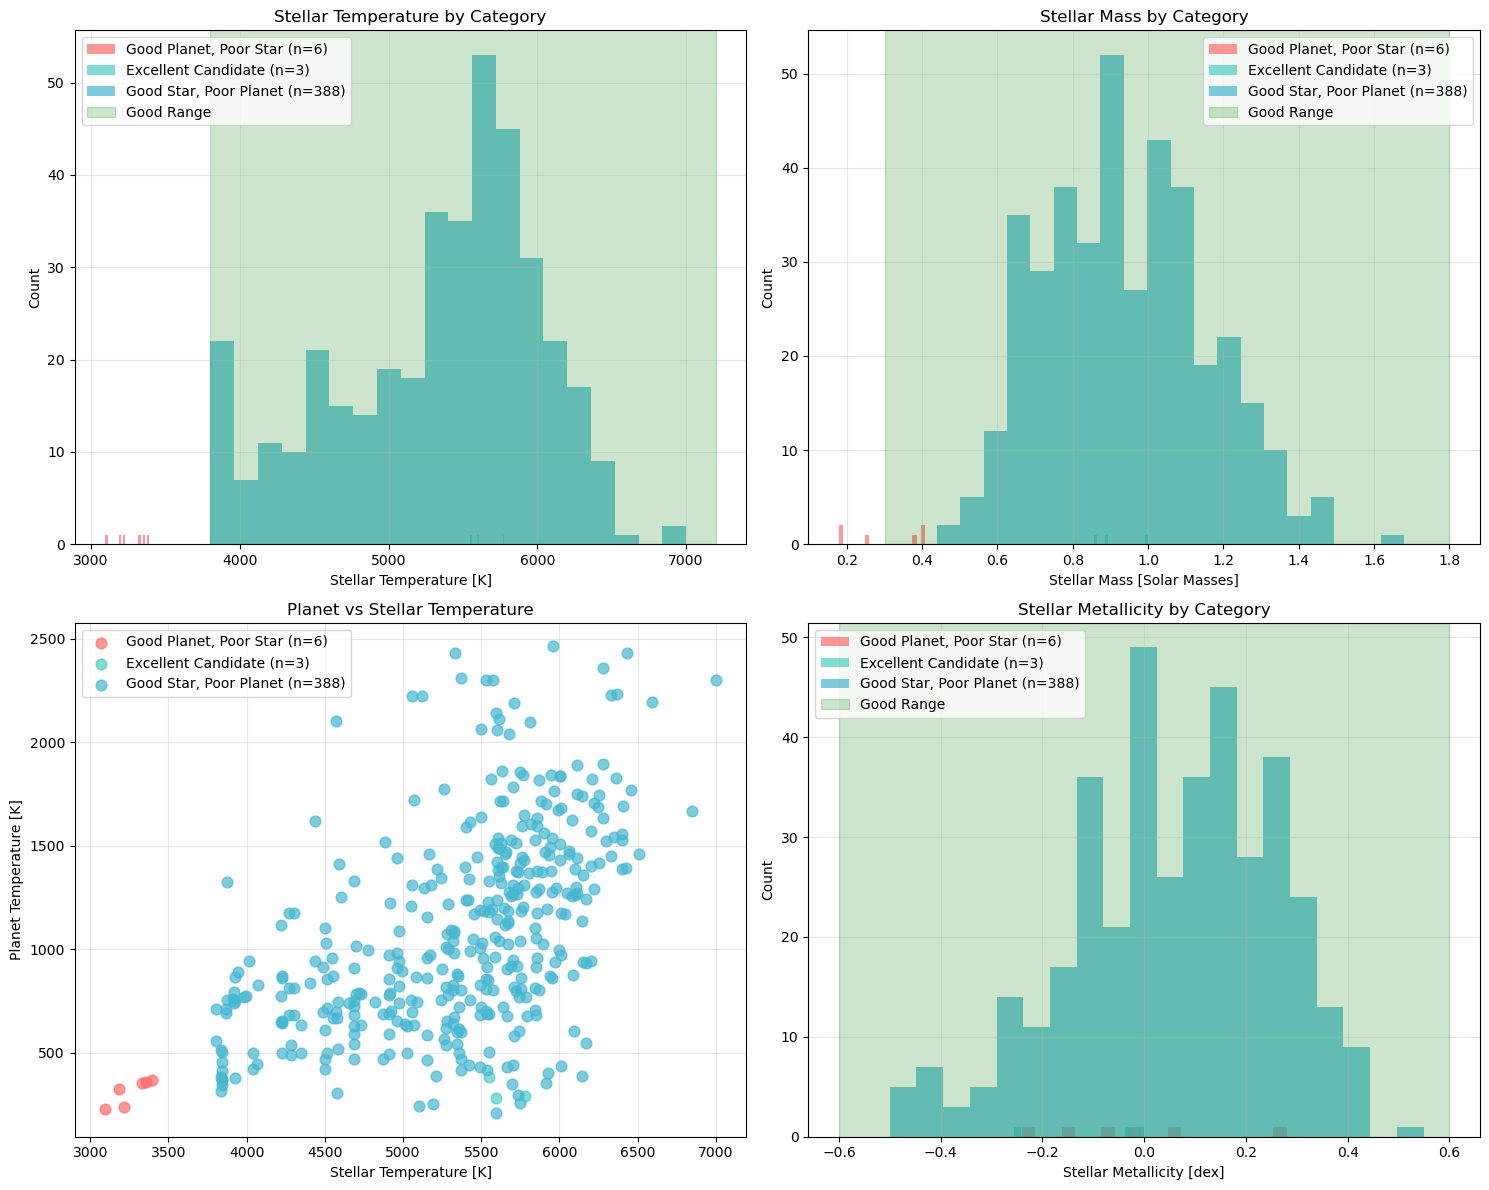


🎯 SUMMARY:
• Found 6 planets with good planetary conditions
• These represent potential 'edge case' habitable worlds
• Main stellar problems: temperature, mass, and metallicity issues
• May still be habitable depending on specific circumstances
• Represent 1.2% of all planets


In [92]:
gpps_analysis = comprehensive_gpps_analysis(df_with_categories, good_ranges)